In [4]:
import os

print(os.getcwd())

c:\Users\81809\OneDrive\ドキュメント\GitHub\DSPP-Infra\notebooks\Shota Emoto


In [7]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score

from scipy.stats import mannwhitneyu

import statsmodels.formula.api as smf

# =====================================================
# 1. LOAD DATA
# =====================================================

ppi = pd.read_csv(
    "../../data/clean/ppi_green_share.csv"
)

resilience = pd.read_csv(
    "../../data/clean/country_resilience_scores.csv"
)

gdp = pd.read_csv(
    "../../data/raw/GDP per capita/db9758b4-95e5-4584-b366-5dd38a5d3769_Data.csv"
)

wgi = pd.read_csv(
    "../../data/raw/rule of law indicator/wgidataset_with_sourcedata-2025.csv"
)

# =====================================================
# 2. PPI DATA
# =====================================================

ppi = ppi[
    [
        "Country",
        "Financial closure year",
        "green_investment",
        "green_share_value"
    ]
].copy()

ppi.rename(
    columns={
        "Financial closure year": "year"
    },
    inplace=True
)

ppi["year"] = pd.to_numeric(
    ppi["year"],
    errors="coerce"
)

# =====================================================
# 3. RESILIENCE
# =====================================================

df = ppi.merge(
    resilience[
        [
            "country",
            "resilience_score"
        ]
    ],
    left_on="Country",
    right_on="country",
    how="left"
)

# =====================================================
# 4. GDP PER CAPITA
# =====================================================

year_cols = [
    c for c in gdp.columns
    if "[YR" in c
]

gdp_long = gdp.melt(
    id_vars=[
        "Country Name",
        "Country Code"
    ],
    value_vars=year_cols,
    var_name="year",
    value_name="gdp_pc"
)

gdp_long["year"] = (
    gdp_long["year"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

gdp_long["gdp_pc"] = pd.to_numeric(
    gdp_long["gdp_pc"],
    errors="coerce"
)

df = df.merge(
    gdp_long[
        [
            "Country Name",
            "year",
            "gdp_pc"
        ]
    ],
    left_on=["Country", "year"],
    right_on=["Country Name", "year"],
    how="left"
)

# =====================================================
# 5. RULE OF LAW
# =====================================================

wgi_rl = wgi[
    wgi["Governance dimension"] == "rl"
].copy()

wgi_rl = wgi_rl[
    [
        "Economy (name)",
        "Year",
        "Governance score (0-100)"
    ]
]

wgi_rl.columns = [
    "Country",
    "year",
    "rule_law"
]

df = df.merge(
    wgi_rl,
    on=["Country", "year"],
    how="left"
)

# =====================================================
# 6. DEPENDENT VARIABLE
# =====================================================

df["log_green"] = np.log1p(
    df["green_investment"]
)

# =====================================================
# 7. CLEAN
# =====================================================

df = df.dropna(
    subset=[
        "log_green",
        "resilience_score",
        "gdp_pc",
        "rule_law"
    ]
).copy()

print(f"N observations = {len(df)}")

print(df["resilience_score"].isna().sum())
print(df["gdp_pc"].isna().sum())
print(df["rule_law"].isna().sum())
print(ppi["Country"].unique()[:30])

print(resilience["country"].unique()[:30])
# =====================================================
# 8. STANDARDIZE
# (same idea as paper)
# =====================================================

z_cols = [
    "resilience_score",
    "gdp_pc",
    "rule_law"
]

scaler = StandardScaler()

df[z_cols] = scaler.fit_transform(
    df[z_cols]
)

# =====================================================
# 9. CLUSTERING
# =====================================================

cluster_vars = [
    "resilience_score",
    "gdp_pc",
    "rule_law"
]

print("\nCalinski-Harabasz scores")

scores = {}

for k in range(2, 7):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(
        df[cluster_vars]
    )

    score = calinski_harabasz_score(
        df[cluster_vars],
        labels
    )

    scores[k] = score

    print(f"k={k}: {score:.2f}")

best_k = max(scores, key=scores.get)

print(f"\nBest k = {best_k}")

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

df["cluster"] = kmeans.fit_predict(
    df[cluster_vars]
)

# =====================================================
# 10. MAIN REGRESSION
# =====================================================

print("\n")
print("=" * 70)
print("FULL SAMPLE REGRESSION")
print("=" * 70)

model = smf.ols(
    """
    log_green
    ~ resilience_score
    + gdp_pc
    + rule_law
    """,
    data=df
).fit(
    cov_type="HC3"
)

print(model.summary())

# =====================================================
# 11. CLUSTER-SPECIFIC REGRESSIONS
# =====================================================

for c in sorted(df["cluster"].unique()):

    tmp = df[
        df["cluster"] == c
    ]

    if len(tmp) < 20:
        continue

    print("\n")
    print("=" * 70)
    print(f"CLUSTER {c}")
    print("=" * 70)

    model_c = smf.ols(
        """
        log_green
        ~ resilience_score
        + gdp_pc
        + rule_law
        """,
        data=tmp
    ).fit(
        cov_type="HC3"
    )

    print(model_c.summary())

# =====================================================
# 12. CLUSTER SUMMARY
# =====================================================

print("\n")
print("=" * 70)
print("CLUSTER CHARACTERISTICS")
print("=" * 70)

summary = (
    df.groupby("cluster")
    [
        [
            "green_investment",
            "green_share_value",
            "resilience_score",
            "gdp_pc",
            "rule_law"
        ]
    ]
    .mean()
)

print(summary)

# =====================================================
# 13. MANN-WHITNEY TESTS
# (paper-style cluster comparison)
# =====================================================

clusters = sorted(df["cluster"].unique())

print("\n")
print("=" * 70)
print("MANN-WHITNEY TESTS")
print("=" * 70)

for i in range(len(clusters)):
    for j in range(i + 1, len(clusters)):

        c1 = clusters[i]
        c2 = clusters[j]

        x = df.loc[
            df["cluster"] == c1,
            "green_investment"
        ]

        y = df.loc[
            df["cluster"] == c2,
            "green_investment"
        ]

        stat, p = mannwhitneyu(
            x,
            y,
            alternative="two-sided"
        )

        print(
            f"Cluster {c1} vs {c2}: "
            f"U={stat:.0f}, p={p:.4f}"
        )

# =====================================================
# 14. SAVE ANALYSIS DATASET
# =====================================================

df.to_csv(
    "data/clean/analysis_dataset.csv",
    index=False
)

print("\nSaved: data/clean/analysis_dataset.csv")

N observations = 0
0
0
0
<StringArray>
[           'Afghanistan',                'Albania',                'Algeria',
                 'Angola',              'Argentina',                'Armenia',
             'Azerbaijan',             'Bangladesh',                'Belarus',
                  'Benin', 'Bosnia and Herzegovina',               'Botswana',
                 'Brazil',               'Bulgaria',           'Burkina Faso',
                'Burundi',             'Cabo Verde',               'Cambodia',
               'Cameroon',                   'Chad',                  'China',
               'Colombia',       'Congo, Dem. Rep.',             'Costa Rica',
          'Côte d'Ivoire',               'Djibouti',     'Dominican Republic',
                'Ecuador',       'Egypt, Arab Rep.',            'El Salvador']
Length: 30, dtype: str
<StringArray>
[                   'China',                'Australia',
                   'Canada',                    'India',
                  'G

ValueError: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by StandardScaler.

In [8]:
import pandas as pd
import numpy as np

# =====================================================
# LOAD
# =====================================================

ppi = pd.read_csv(
    "../../data/clean/ppi_green_share.csv"
)

resilience = pd.read_csv(
    "../../data/clean/country_resilience_scores.csv"
)

gdp = pd.read_csv(
    "../../data/raw/GDP per capita/db9758b4-95e5-4584-b366-5dd38a5d3769_Data.csv"
)

wgi = pd.read_csv(
    "../../data/raw/rule of law indicator/wgidataset_with_sourcedata-2025.csv"
)

print("="*60)
print("RAW DATA")
print("="*60)

print("PPI:", ppi.shape)
print("RESILIENCE:", resilience.shape)
print("GDP:", gdp.shape)
print("WGI:", wgi.shape)

# =====================================================
# PPI
# =====================================================

ppi = ppi[
    [
        "Country",
        "Financial closure year",
        "green_investment"
    ]
].copy()

ppi.rename(
    columns={
        "Financial closure year": "year"
    },
    inplace=True
)

print("\n")
print("="*60)
print("PPI COUNTRIES")
print("="*60)

print(ppi["Country"].nunique())
print(ppi["Country"].drop_duplicates().head(20))

# =====================================================
# RESILIENCE MERGE
# =====================================================

test1 = ppi.merge(
    resilience,
    left_on="Country",
    right_on="country",
    how="left"
)

print("\n")
print("="*60)
print("RESILIENCE MERGE")
print("="*60)

print("rows:", len(test1))
print(
    "matched:",
    test1["resilience_score"].notna().sum()
)

print(
    "missing:",
    test1["resilience_score"].isna().sum()
)

print(
    test1.loc[
        test1["resilience_score"].isna(),
        "Country"
    ]
    .drop_duplicates()
    .head(30)
    .tolist()
)

# =====================================================
# GDP LONG
# =====================================================

year_cols = [
    c for c in gdp.columns
    if "[YR" in c
]

print("\n")
print("="*60)
print("GDP")
print("="*60)

print("year columns:", len(year_cols))

gdp_long = gdp.melt(
    id_vars=[
        "Country Name",
        "Country Code"
    ],
    value_vars=year_cols,
    var_name="year",
    value_name="gdp_pc"
)

gdp_long["year"] = (
    gdp_long["year"]
    .str.extract(r"(\d{4})")
)

gdp_long["gdp_pc"] = pd.to_numeric(
    gdp_long["gdp_pc"],
    errors="coerce"
)

gdp_long = gdp_long.dropna(
    subset=["year"]
)

gdp_long["year"] = gdp_long["year"].astype(int)

print(gdp_long.head())

# =====================================================
# GDP MERGE
# =====================================================

test2 = test1.merge(
    gdp_long[
        [
            "Country Name",
            "year",
            "gdp_pc"
        ]
    ],
    left_on=["Country", "year"],
    right_on=["Country Name", "year"],
    how="left"
)

print("\n")
print("="*60)
print("GDP MERGE")
print("="*60)

print(
    "GDP matched:",
    test2["gdp_pc"].notna().sum()
)

print(
    "GDP missing:",
    test2["gdp_pc"].isna().sum()
)

print(
    test2.loc[
        test2["gdp_pc"].isna(),
        "Country"
    ]
    .drop_duplicates()
    .head(30)
    .tolist()
)

# =====================================================
# WGI
# =====================================================

print("\n")
print("="*60)
print("GOVERNANCE DIMENSIONS")
print("="*60)

print(
    wgi["Governance dimension"]
    .drop_duplicates()
    .tolist()
)

# Rule of Law抽出

wgi_rl = wgi[
    wgi["Governance dimension"] == "rl"
].copy()

print("\nRule of law rows:", len(wgi_rl))

wgi_rl = wgi_rl[
    [
        "Economy (name)",
        "Year",
        "Governance score (0-100)"
    ]
]

wgi_rl.columns = [
    "Country",
    "year",
    "rule_law"
]

# =====================================================
# WGI MERGE
# =====================================================

test3 = test2.merge(
    wgi_rl,
    on=["Country", "year"],
    how="left"
)

print("\n")
print("="*60)
print("RULE OF LAW MERGE")
print("="*60)

print(
    "Rule of law matched:",
    test3["rule_law"].notna().sum()
)

print(
    "Rule of law missing:",
    test3["rule_law"].isna().sum()
)

print(
    test3.loc[
        test3["rule_law"].isna(),
        "Country"
    ]
    .drop_duplicates()
    .head(30)
    .tolist()
)

# =====================================================
# FINAL
# =====================================================

print("\n")
print("="*60)
print("FINAL NON-MISSING")
print("="*60)

print(
    test3[
        [
            "resilience_score",
            "gdp_pc",
            "rule_law"
        ]
    ]
    .notna()
    .sum()
)

print("\nRows surviving complete case:")

complete = test3.dropna(
    subset=[
        "resilience_score",
        "gdp_pc",
        "rule_law"
    ]
)

print(len(complete))

print("\nSample rows")

print(
    complete[
        [
            "Country",
            "year",
            "resilience_score",
            "gdp_pc",
            "rule_law"
        ]
    ]
    .head()
)

RAW DATA
PPI: (556, 14)
RESILIENCE: (189, 4)
GDP: (271, 70)
WGI: (5444, 51)


PPI COUNTRIES
100
0                Afghanistan
2                    Albania
7                    Algeria
8                     Angola
10                 Argentina
21                   Armenia
26                Azerbaijan
30                Bangladesh
45                   Belarus
46                     Benin
48    Bosnia and Herzegovina
52                  Botswana
56                    Brazil
71                  Bulgaria
79              Burkina Faso
82                   Burundi
85                Cabo Verde
87                  Cambodia
93                  Cameroon
96                      Chad
Name: Country, dtype: str


RESILIENCE MERGE
rows: 556
matched: 496
missing: 60
['Cabo Verde', 'Congo, Dem. Rep.', "Côte d'Ivoire", 'Egypt, Arab Rep.', 'Iran, Islamic Rep.', 'Kosovo', 'Kyrgyz Republic', 'Lao PDR', 'North Macedonia', 'Serbia ', 'St. Kitts and Nevis', 'St. Lucia', 'St. Vincent and the Grenadines', 'São Tomé 

In [9]:
import pandas as pd
import numpy as np

print("=" * 80)
print("LOAD FILES")
print("=" * 80)

ppi = pd.read_csv(
    "../../data/clean/ppi_green_share.csv"
)

resilience = pd.read_csv(
    "../../data/clean/country_resilience_scores.csv"
)

gdp = pd.read_csv(
    "../../data/raw/GDP per capita/db9758b4-95e5-4584-b366-5dd38a5d3769_Data.csv"
)

wgi = pd.read_csv(
    "../../data/raw/rule of law indicator/wgidataset_with_sourcedata-2025.csv",
    low_memory=False
)

print("PPI shape:", ppi.shape)
print("Resilience shape:", resilience.shape)
print("GDP shape:", gdp.shape)
print("WGI shape:", wgi.shape)

print("\n")
print("=" * 80)
print("WGI BASIC INFO")
print("=" * 80)

print("\nColumns:")
print(wgi.columns.tolist())

print("\nGovernance dimensions:")

print(
    wgi["Governance dimension"]
    .value_counts(dropna=False)
)

print("\nUnique dimensions:")

print(
    sorted(
        wgi["Governance dimension"]
        .dropna()
        .unique()
    )
)

print("\nFirst 5 rows:")
print(wgi.head())

print("\nLast 5 rows:")
print(wgi.tail())

print("\n")
print("=" * 80)
print("CHECK FOR RULE OF LAW")
print("=" * 80)

rl_rows = wgi[
    wgi["Governance dimension"] == "rl"
]

print("Rule of law rows:", len(rl_rows))

if len(rl_rows) > 0:

    print("\nSample RL rows")

    print(
        rl_rows[
            [
                "Economy (name)",
                "Year",
                "Governance dimension",
                "Governance score (0-100)"
            ]
        ].head()
    )

else:

    print(
        "\nNo 'rl' rows found."
    )

print("\n")
print("=" * 80)
print("PPI COUNTRY SAMPLE")
print("=" * 80)

print(
    sorted(
        ppi["Country"]
        .dropna()
        .unique()
    )[:30]
)

print("\n")
print("=" * 80)
print("RESILIENCE COUNTRY SAMPLE")
print("=" * 80)

print(
    sorted(
        resilience["country"]
        .dropna()
        .unique()
    )[:30]
)

print("\n")
print("=" * 80)
print("RESILIENCE MERGE TEST")
print("=" * 80)

tmp = ppi.merge(
    resilience[
        [
            "country",
            "resilience_score"
        ]
    ],
    left_on="Country",
    right_on="country",
    how="left"
)

print("Total rows:", len(tmp))

print(
    "Matched:",
    tmp["resilience_score"]
    .notna()
    .sum()
)

print(
    "Missing:",
    tmp["resilience_score"]
    .isna()
    .sum()
)

print("\nMissing country examples:")

print(
    tmp.loc[
        tmp["resilience_score"].isna(),
        "Country"
    ]
    .drop_duplicates()
    .tolist()[:30]
)

print("\n")
print("=" * 80)
print("GDP TEST")
print("=" * 80)

year_cols = [
    c
    for c in gdp.columns
    if "[YR" in c
]

print(
    "Number of year columns:",
    len(year_cols)
)

gdp_long = gdp.melt(
    id_vars=[
        "Country Name",
        "Country Code"
    ],
    value_vars=year_cols,
    var_name="year",
    value_name="gdp_pc"
)

gdp_long["year"] = (
    gdp_long["year"]
    .str.extract(r"(\d{4})")
)

gdp_long = gdp_long.dropna(
    subset=["year"]
)

gdp_long["year"] = (
    gdp_long["year"]
    .astype(int)
)

gdp_long["gdp_pc"] = pd.to_numeric(
    gdp_long["gdp_pc"],
    errors="coerce"
)

print(
    gdp_long.head()
)

print("\nGDP non-missing:")

print(
    gdp_long["gdp_pc"]
    .notna()
    .sum()
)

print("\n")
print("=" * 80)
print("GDP MERGE TEST")
print("=" * 80)

ppi2 = ppi.copy()

ppi2.rename(
    columns={
        "Financial closure year": "year"
    },
    inplace=True
)

ppi2["year"] = pd.to_numeric(
    ppi2["year"],
    errors="coerce"
)

tmp2 = ppi2.merge(
    gdp_long[
        [
            "Country Name",
            "year",
            "gdp_pc"
        ]
    ],
    left_on=["Country", "year"],
    right_on=["Country Name", "year"],
    how="left"
)

print(
    "GDP matched:",
    tmp2["gdp_pc"]
    .notna()
    .sum()
)

print(
    "GDP missing:",
    tmp2["gdp_pc"]
    .isna()
    .sum()
)

print(
    "\nGDP missing examples:"
)

print(
    tmp2.loc[
        tmp2["gdp_pc"].isna(),
        "Country"
    ]
    .drop_duplicates()
    .tolist()[:30]
)

print("\n")
print("=" * 80)
print("FINAL DIAGNOSIS")
print("=" * 80)

print("""
確認ポイント

① Governance dimension に rl があるか？
② WGI shape が 30000行以上か？
③ value_counts に va, pv, ge, rq, rl, cc が並ぶか？
④ rl_rows > 0 か？

もし rl_rows = 0 なら、
その CSV は Voice & Accountability (va) 専用ファイルです。
""")

LOAD FILES
PPI shape: (556, 14)
Resilience shape: (189, 4)
GDP shape: (271, 70)
WGI shape: (5444, 51)


WGI BASIC INFO

Columns:
['ID variable (economy code/ gov. dimension/ year)', 'Economy (name)', 'Economy (code)', 'Region', 'Income classification', 'Year', 'Governance dimension', 'Number of sources', 'Governance estimate (approx. -2.5 to +2.5)', 'Standard error (estimate)', 'Lower threshold (90% conf. int. estimate)', 'Upper threshold (90% conf. int. estimate)', 'Governance score (0-100)', 'Standard error (gov. score)', 'Lower threshold (90% conf. int. score)', 'Upper threshold (90% conf. int. score)', 'ADB mean', 'AFR mean', 'ARB mean', 'ASB mean', 'ASD mean', 'BPS mean', 'BTI mean', 'CCR mean', 'EBR mean', 'EIU mean', 'EQI mean', 'EUB mean', 'FRH mean', 'GCB mean', 'GCS mean', 'GII mean', 'GWP mean', 'HER mean', 'HRM mean', 'HUM mean', 'IFD mean', 'IJT mean', 'IRP mean', 'LBO mean', 'MSI mean', 'OBI mean', 'PIA mean', 'PRS mean', 'RSF mean', 'VAB mean', 'VDM mean', 'WBS mean', 'W

In [10]:
import pandas as pd

xlsx_path = "../../data/raw/rule of law indicator/wgidataset_with_sourcedata-2025.xlsx"

xls = pd.ExcelFile(xlsx_path)

print(xls.sheet_names)

['va', 'pv', 'ge', 'rq', 'rl', 'cc']


In [11]:
import pandas as pd

xlsx_path = "../../data/raw/rule of law indicator/wgidataset_with_sourcedata-2025.xlsx"

df = pd.read_excel(xlsx_path)

print(
    df["Governance dimension"]
    .value_counts()
)

rl = df[
    df["Governance dimension"] == "rl"
].copy()

print("RL rows:", len(rl))

rl.to_csv(
    "../../data/raw/rule of law indicator/rule_of_law.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved: rule_of_law.csv")

Governance dimension
va    5444
Name: count, dtype: int64
RL rows: 0
Saved: rule_of_law.csv


In [1]:
import pandas as pd

xlsx_path = "../../data/raw/rule of law indicator/wgidataset_with_sourcedata-2025.xlsx"

df = pd.read_excel(
    xlsx_path,
    sheet_name="rl",
    header=None
)

print(df.shape)

print(df.head(20))

(5477, 51)
                                                  0                     1   \
0   ID variable (economy code/ gov. dimension/ year)        Economy (name)   
1                                          ADOrl1996               Andorra   
2                                          AFGrl1996           Afghanistan   
3                                          AGOrl1996                Angola   
4                                          ALBrl1996               Albania   
5                                          ARErl1996  United Arab Emirates   
6                                          ARGrl1996             Argentina   
7                                          ARMrl1996               Armenia   
8                                          ATGrl1996   Antigua and Barbuda   
9                                          AUSrl1996             Australia   
10                                         AUTrl1996               Austria   
11                                         AZErl1996 

In [2]:
import pandas as pd

xlsx_path = "../../data/raw/rule of law indicator/wgidataset_with_sourcedata-2025.xlsx"

df = pd.read_excel(
    xlsx_path,
    sheet_name="rl"
)

print(df.shape)
print(df.head())

df.to_csv(
    "../../data/raw/rule of law indicator/rule_of_law.csv",
    index=False,
    encoding="utf-8-sig"
)

print("saved")

(5476, 51)
  ID variable (economy code/ gov. dimension/ year)        Economy (name)  \
0                                        ADOrl1996               Andorra   
1                                        AFGrl1996           Afghanistan   
2                                        AGOrl1996                Angola   
3                                        ALBrl1996               Albania   
4                                        ARErl1996  United Arab Emirates   

  Economy (code)                      Region Income classification  Year  \
0            ADO                         NaN                   NaN  1996   
1            AFG                  South Asia            Low income  1996   
2            AGO          Sub-Saharan Africa   Lower middle income  1996   
3            ALB       Europe & Central Asia   Upper middle income  1996   
4            ARE  Middle East & North Africa           High income  1996   

  Governance dimension  Number of sources  \
0                   rl        

In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score

from scipy.stats import mannwhitneyu

import statsmodels.formula.api as smf

# =====================================================
# 1. LOAD DATA
# =====================================================

ppi = pd.read_csv(
    "../../data/clean/ppi_green_share.csv"
)

resilience = pd.read_csv(
    "../../data/clean/country_resilience_scores.csv"
)

gdp = pd.read_csv(
    "../../data/raw/GDP per capita/db9758b4-95e5-4584-b366-5dd38a5d3769_Data.csv"
)

wgi = pd.read_csv(
    "../../data/raw/rule of law indicator/rule_of_law.csv"
)

# =====================================================
# 2. PPI DATA
# =====================================================

ppi = ppi[
    [
        "Country",
        "Financial closure year",
        "green_investment",
        "green_share_value"
    ]
].copy()

ppi.rename(
    columns={
        "Financial closure year": "year"
    },
    inplace=True
)

ppi["year"] = pd.to_numeric(
    ppi["year"],
    errors="coerce"
)

# =====================================================
# 3. RESILIENCE
# =====================================================

df = ppi.merge(
    resilience[
        [
            "country",
            "resilience_score"
        ]
    ],
    left_on="Country",
    right_on="country",
    how="left"
)

# =====================================================
# 4. GDP PER CAPITA
# =====================================================

year_cols = [
    c for c in gdp.columns
    if "[YR" in c
]

gdp_long = gdp.melt(
    id_vars=[
        "Country Name",
        "Country Code"
    ],
    value_vars=year_cols,
    var_name="year",
    value_name="gdp_pc"
)

gdp_long["year"] = (
    gdp_long["year"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

gdp_long["gdp_pc"] = pd.to_numeric(
    gdp_long["gdp_pc"],
    errors="coerce"
)

df = df.merge(
    gdp_long[
        [
            "Country Name",
            "year",
            "gdp_pc"
        ]
    ],
    left_on=["Country", "year"],
    right_on=["Country Name", "year"],
    how="left"
)

# =====================================================
# 5. RULE OF LAW
# =====================================================

wgi_rl = wgi[
    wgi["Governance dimension"] == "rl"
].copy()

wgi_rl = wgi_rl[
    [
        "Economy (name)",
        "Year",
        "Governance score (0-100)"
    ]
]

wgi_rl.columns = [
    "Country",
    "year",
    "rule_law"
]

df = df.merge(
    wgi_rl,
    on=["Country", "year"],
    how="left"
)

# =====================================================
# 6. DEPENDENT VARIABLE
# =====================================================

df["log_green"] = np.log1p(
    df["green_investment"]
)

# =====================================================
# 7. CLEAN
# =====================================================

df = df.dropna(
    subset=[
        "log_green",
        "resilience_score",
        "gdp_pc",
        "rule_law"
    ]
).copy()

print(f"N observations = {len(df)}")

print(df["resilience_score"].isna().sum())
print(df["gdp_pc"].isna().sum())
print(df["rule_law"].isna().sum())
print(ppi["Country"].unique()[:30])

print(resilience["country"].unique()[:30])
# =====================================================
# 8. STANDARDIZE
# (same idea as paper)
# =====================================================

z_cols = [
    "resilience_score",
    "gdp_pc",
    "rule_law"
]

scaler = StandardScaler()

df[z_cols] = scaler.fit_transform(
    df[z_cols]
)

# =====================================================
# 9. CLUSTERING
# =====================================================

cluster_vars = [
    "resilience_score",
    "gdp_pc",
    "rule_law"
]

print("\nCalinski-Harabasz scores")

scores = {}

for k in range(2, 7):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(
        df[cluster_vars]
    )

    score = calinski_harabasz_score(
        df[cluster_vars],
        labels
    )

    scores[k] = score

    print(f"k={k}: {score:.2f}")

best_k = max(scores, key=scores.get)

print(f"\nBest k = {best_k}")

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

df["cluster"] = kmeans.fit_predict(
    df[cluster_vars]
)

# =====================================================
# 10. MAIN REGRESSION
# =====================================================

print("\n")
print("=" * 70)
print("FULL SAMPLE REGRESSION")
print("=" * 70)

model = smf.ols(
    """
    log_green
    ~ resilience_score
    + gdp_pc
    + rule_law
    """,
    data=df
).fit(
    cov_type="HC3"
)

print(model.summary())

# =====================================================
# 11. CLUSTER-SPECIFIC REGRESSIONS
# =====================================================

for c in sorted(df["cluster"].unique()):

    tmp = df[
        df["cluster"] == c
    ]

    if len(tmp) < 20:
        continue

    print("\n")
    print("=" * 70)
    print(f"CLUSTER {c}")
    print("=" * 70)

    model_c = smf.ols(
        """
        log_green
        ~ resilience_score
        + gdp_pc
        + rule_law
        """,
        data=tmp
    ).fit(
        cov_type="HC3"
    )

    print(model_c.summary())

# =====================================================
# 12. CLUSTER SUMMARY
# =====================================================

print("\n")
print("=" * 70)
print("CLUSTER CHARACTERISTICS")
print("=" * 70)

summary = (
    df.groupby("cluster")
    [
        [
            "green_investment",
            "green_share_value",
            "resilience_score",
            "gdp_pc",
            "rule_law"
        ]
    ]
    .mean()
)

print(summary)

# =====================================================
# 13. MANN-WHITNEY TESTS
# (paper-style cluster comparison)
# =====================================================

clusters = sorted(df["cluster"].unique())

print("\n")
print("=" * 70)
print("MANN-WHITNEY TESTS")
print("=" * 70)

for i in range(len(clusters)):
    for j in range(i + 1, len(clusters)):

        c1 = clusters[i]
        c2 = clusters[j]

        x = df.loc[
            df["cluster"] == c1,
            "green_investment"
        ]

        y = df.loc[
            df["cluster"] == c2,
            "green_investment"
        ]

        stat, p = mannwhitneyu(
            x,
            y,
            alternative="two-sided"
        )

        print(
            f"Cluster {c1} vs {c2}: "
            f"U={stat:.0f}, p={p:.4f}"
        )

# =====================================================
# 14. SAVE ANALYSIS DATASET
# =====================================================

df.to_csv(
    "../../data/clean/analysis_dataset.csv",
    index=False
)

print("\nSaved: data/clean/analysis_dataset.csv")

N observations = 463
0
0
0
<StringArray>
[           'Afghanistan',                'Albania',                'Algeria',
                 'Angola',              'Argentina',                'Armenia',
             'Azerbaijan',             'Bangladesh',                'Belarus',
                  'Benin', 'Bosnia and Herzegovina',               'Botswana',
                 'Brazil',               'Bulgaria',           'Burkina Faso',
                'Burundi',             'Cabo Verde',               'Cambodia',
               'Cameroon',                   'Chad',                  'China',
               'Colombia',       'Congo, Dem. Rep.',             'Costa Rica',
          'Côte d'Ivoire',               'Djibouti',     'Dominican Republic',
                'Ecuador',       'Egypt, Arab Rep.',            'El Salvador']
Length: 30, dtype: str
<StringArray>
[                   'China',                'Australia',
                   'Canada',                    'India',
                  

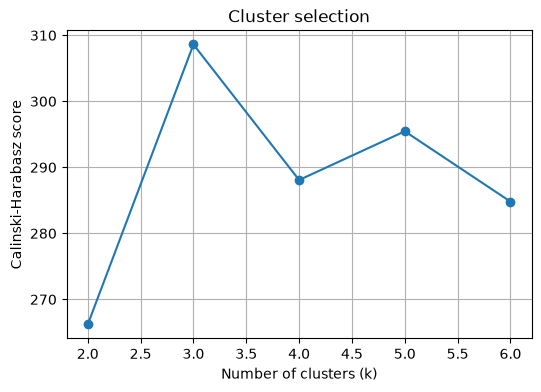

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(
    list(scores.keys()),
    list(scores.values()),
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz score")
plt.title("Cluster selection")

plt.grid(True)

plt.show()

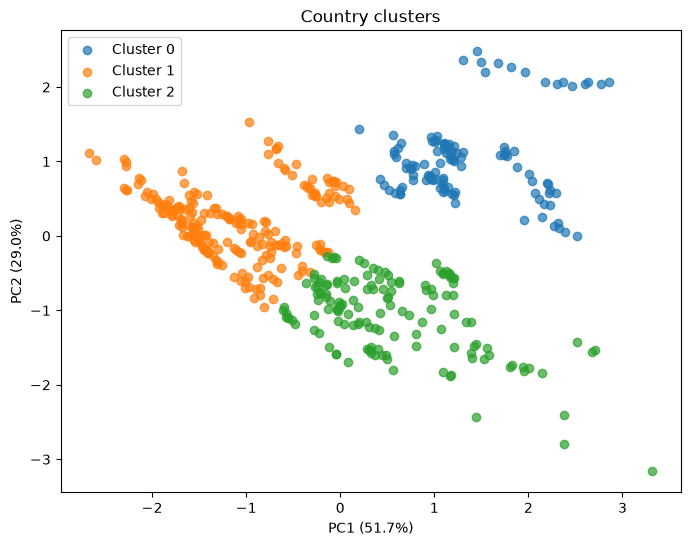

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = df[cluster_vars]

pca = PCA(n_components=2)

coords = pca.fit_transform(X)

plot_df = pd.DataFrame({
    "PC1": coords[:,0],
    "PC2": coords[:,1],
    "cluster": df["cluster"]
})

plt.figure(figsize=(8,6))

for c in sorted(plot_df["cluster"].unique()):

    tmp = plot_df[
        plot_df["cluster"] == c
    ]

    plt.scatter(
        tmp["PC1"],
        tmp["PC2"],
        label=f"Cluster {c}",
        alpha=0.7
    )

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

plt.legend()
plt.title("Country clusters")

plt.show()

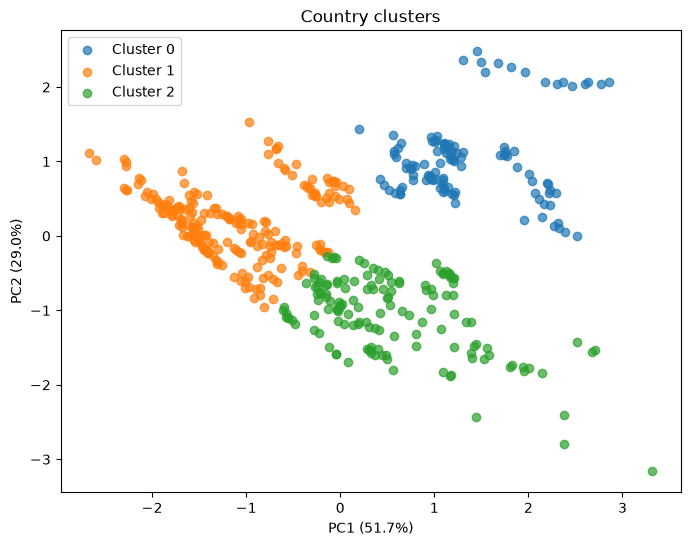

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = df[cluster_vars]

pca = PCA(n_components=2)

coords = pca.fit_transform(X)

plot_df = pd.DataFrame({
    "PC1": coords[:,0],
    "PC2": coords[:,1],
    "cluster": df["cluster"]
})

plt.figure(figsize=(8,6))

for c in sorted(plot_df["cluster"].unique()):

    tmp = plot_df[
        plot_df["cluster"] == c
    ]

    plt.scatter(
        tmp["PC1"],
        tmp["PC2"],
        label=f"Cluster {c}",
        alpha=0.7
    )

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

plt.legend()
plt.title("Country clusters")

plt.show()

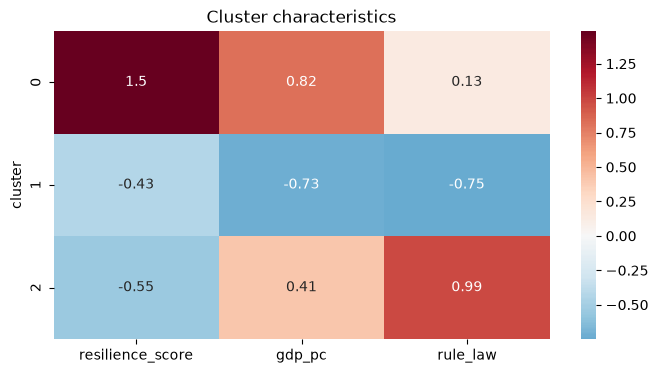

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_profile = (
    df.groupby("cluster")
    [
        [
            "resilience_score",
            "gdp_pc",
            "rule_law"
        ]
    ]
    .mean()
)

plt.figure(figsize=(8,4))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.title("Cluster characteristics")

plt.show()